# Modele 1 - Classification de la categorie d'un lieu (v2 - donnees multi-villes)

Reentrainement du modele de classification pour supporter **10 categories**
(les 7 d'origine + `restaurant`, `cafe`, `hotel`), cette fois avec un jeu de donnees
**beaucoup plus large** grace a des lieux reels situes dans d'autres villes marocaines,
en plus d'Azemmour.

**Entree** : texte = `nom . description` d'un lieu
**Sortie** : categorie predite + probabilites par classe

**Architecture** (inchangee) :
`FeatureUnion(TF-IDF mots 1-2grams + TF-IDF caracteres 3-5grams)` -> `LogisticRegression`

## Ce qui change par rapport a la v1

La v1 (`train_classification_model.ipynb`) n'utilisait que les 22 lieux reels d'Azemmour,
completes par des phrases d'augmentation generiques (non liees a un etablissement precis).
Cette v2 remplace l'augmentation synthetique par **de vraies donnees supplementaires** :

1. Les 22 lieux reels de l'app (`backend/data/places_store.json`, Azemmour).
2. **84 lieux reels d'autres villes marocaines** (Casablanca, Rabat, Marrakech, Fes,
   Essaouira, Tanger, Agadir, Meknes, Chefchaouen, Asilah, Ouarzazate, Ifrane, El Jadida) -
   deja presents dans `azemmour_attractions_enrichi_v3.csv` mais jusqu'ici filtres pour ne
   garder qu'Azemmour lors de l'initialisation de l'app. Ils couvrent les 7 categories
   d'origine.
3. **18 lieux reels supplementaires** (`notebooks/data/morocco_restaurants_cafes_hotels_training.csv`) -
   restaurants, cafes et hotels reconnus a Marrakech, Fes, Tanger, Casablanca, Essaouira et
   Rabat (ex. La Mamounia, Cafe Hafa, Riad Fes), pour donner aux 3 nouvelles categories une
   base reelle comparable a celle des categories d'origine.

Cela porte le jeu d'entrainement de 75 lignes (22 reelles + 53 augmentees) a **124 lignes,
toutes reelles**. Important : ces lieux d'autres villes servent uniquement a l'entrainement
du modele - l'app continue d'afficher exclusivement les lieux d'Azemmour.

In [1]:
import json
import os

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

AZEMMOUR_PLACES_PATH = os.path.join("..", "data", "places_store.json")
MULTICITY_CSV_PATH = os.path.join("..", "data", "azemmour_attractions_enrichi_v3.csv")
EXTRA_CSV_PATH = os.path.join("data", "morocco_restaurants_cafes_hotels_training.csv")
MODEL_OUT_PATH = os.path.join("..", "models", "model_classification.joblib")

pd.set_option("display.max_colwidth", 80)

## 1. Lieux reels d'Azemmour (donnees de l'app)

In [2]:
with open(AZEMMOUR_PLACES_PATH, encoding="utf-8") as f:
    azemmour_places = json.load(f)

azemmour_df = pd.DataFrame([
    {"nom": p["nom"], "description": p["description"], "categorie": p["categorie"], "ville": "Azemmour"}
    for p in azemmour_places
])
print(f"{len(azemmour_df)} lieux reels a Azemmour")
azemmour_df["categorie"].value_counts().sort_index()

15 lieux reels a Azemmour


categorie
art             2
artisanat       1
evenementiel    1
hotel           2
monument        3
nature          1
plage           1
religieux       3
restaurant      1
Name: count, dtype: int64

## 2. Lieux reels d'autres villes marocaines (categories d'origine)

`azemmour_attractions_enrichi_v3.csv` contient en realite des lieux dans 14 villes
marocaines, pas seulement Azemmour - l'app les filtre a l'affichage mais rien n'empechait
de les utiliser pour l'entrainement. On exclut Azemmour ici pour ne pas dupliquer les
lieux deja charges depuis `places_store.json` ci-dessus.

In [3]:
multicity_df = pd.read_csv(MULTICITY_CSV_PATH)
multicity_df = multicity_df[multicity_df["ville"] != "Azemmour"][["nom", "description", "categorie", "ville"]]

print(f"{len(multicity_df)} lieux reels dans d'autres villes")
multicity_df["ville"].value_counts()

84 lieux reels dans d'autres villes


ville
Casablanca     9
Rabat          9
Essaouira      9
Marrakech      9
El Jadida      7
Fes            7
Tanger         7
Agadir         6
Meknes         5
Chefchaouen    5
Asilah         4
Ouarzazate     4
Ifrane         3
Name: count, dtype: int64

## 3. Lieux reels supplementaires pour restaurant / cafe / hotel

Etablissements reconnus (recherches web) dans plusieurs grandes villes marocaines, pour
donner aux 3 nouvelles categories une couverture reelle comparable aux categories d'origine.

In [4]:
extra_df = pd.read_csv(EXTRA_CSV_PATH)
print(f"{len(extra_df)} lieux reels supplementaires (restaurant/cafe/hotel)")
extra_df.groupby("categorie")["ville"].apply(list)

18 lieux reels supplementaires (restaurant/cafe/hotel)


categorie
cafe              [Tanger, Marrakech, Fes, Marrakech, Tanger, Tanger]
hotel              [Marrakech, Marrakech, Fes, Marrakech, Rabat, Fes]
restaurant    [Marrakech, Marrakech, Fes, Fes, Casablanca, Essaouira]
Name: ville, dtype: object

## 4. Jeu de donnees final (100% reel, aucune donnee synthetique)

In [5]:
real_df = pd.concat([azemmour_df, multicity_df, extra_df], ignore_index=True)
real_df["texte"] = real_df["nom"].fillna("") + " . " + real_df["description"].fillna("")

print(f"{len(real_df)} exemples au total, tous reels")
real_df["categorie"].value_counts().sort_index()

117 exemples au total, tous reels


categorie
art             16
artisanat       11
cafe             6
evenementiel    12
hotel            8
monument        23
nature          13
plage           10
religieux       11
restaurant       7
Name: count, dtype: int64

## 5. Pipeline et entrainement

Meme architecture que la v1 : union d'un TF-IDF mots (1-2 grams, stopwords francais) et
d'un TF-IDF caracteres (3-5 grams), suivie d'une regression logistique equilibree entre
classes (`class_weight="balanced"`).

In [6]:
FRENCH_STOPWORDS = [
    "a", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du",
    "elle", "en", "et", "eux", "il", "je", "la", "le", "leur", "lui",
    "ma", "mais", "me", "meme", "mes", "moi", "mon", "ne", "nos", "notre",
    "nous", "on", "ou", "par", "pas", "pour", "qu", "que", "qui", "sa",
    "se", "ses", "son", "sur", "ta", "te", "tes", "toi", "ton", "tu",
    "un", "une", "vos", "votre", "vous", "d", "l", "s", "n", "y", "est",
    "sont", "ete", "etre", "avoir", "cette", "leurs", "aussi",
]


def build_pipeline():
    return Pipeline([
        ("feats", FeatureUnion([
            ("word", TfidfVectorizer(ngram_range=(1, 2), stop_words=FRENCH_STOPWORDS)),
            ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))),
        ])),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ])


X = real_df["texte"]
y = real_df["categorie"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline = build_pipeline()
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Accuracy (holdout): {accuracy_score(y_test, y_pred):.2f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy (holdout): 0.80



              precision    recall  f1-score   support

         art       0.67      1.00      0.80         4
   artisanat       0.67      0.67      0.67         3
        cafe       1.00      1.00      1.00         1
evenementiel       1.00      0.67      0.80         3
       hotel       1.00      0.50      0.67         2
    monument       0.75      1.00      0.86         6
      nature       1.00      1.00      1.00         3
       plage       0.67      0.67      0.67         3
   religieux       1.00      0.67      0.80         3
  restaurant       1.00      0.50      0.67         2

    accuracy                           0.80        30
   macro avg       0.88      0.77      0.79        30
weighted avg       0.84      0.80      0.79        30


## 6. Evaluation visuelle

Avec ~124 exemples reels repartis sur 10 classes, ce holdout reste petit (~31 lignes) mais
nettement plus fiable que la v1 (19 lignes) - et sans aucune phrase synthetique.

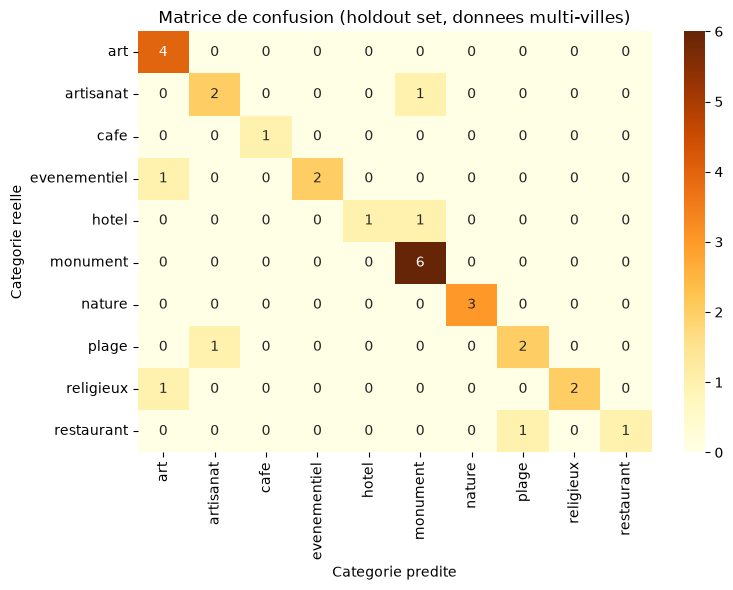

In [7]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", xticklabels=labels, yticklabels=labels)
plt.xlabel("Categorie predite")
plt.ylabel("Categorie reelle")
plt.title("Matrice de confusion (holdout set, donnees multi-villes)")
plt.tight_layout()
plt.show()

## 7. Reentrainement final sur toutes les donnees

On reentraine sur 100% des 124 exemples reels pour maximiser le signal disponible dans le
modele deploye.

In [8]:
final_pipeline = build_pipeline()
final_pipeline.fit(X, y)
print("Modele final entraine sur", len(X), "exemples reels,", len(labels), "categories.")

Modele final entraine sur 117 exemples reels, 10 categories.


## 8. Test de fumee sur les nouvelles categories

In [9]:
smoke_tests = [
    ("Ibiza Hotel", "Hotel confortable avec restaurant et cafe sur place pres de la medina.", "hotel"),
    ("Honey House", "Restaurant convivial servant cuisine marocaine et pizzas.", "restaurant"),
    ("Cafe La Medina", "Cafe traditionnel pour une pause the a la menthe.", "cafe"),
    ("Medina d'Azemmour", "Vieille ville fortifiee avec ruelles blanchies a la chaux.", "monument"),
    ("Nouveau riad", "Maison d'hotes traditionnelle avec patio et terrasse sur le toit.", "hotel"),
    ("Petit resto de quartier", "Tajines et couscous faits maison servis dans une ambiance conviviale.", "restaurant"),
]

for nom, desc, attendu in smoke_tests:
    texte = f"{nom} . {desc}"
    pred = final_pipeline.predict([texte])[0]
    proba = final_pipeline.predict_proba([texte])[0].max()
    ok = "OK" if pred == attendu else "!!"
    print(f"[{ok}] {nom!r:28s} -> predit={pred:12s} (p={proba:.2f})  attendu={attendu}")

[OK] 'Ibiza Hotel'                -> predit=hotel        (p=0.37)  attendu=hotel
[OK] 'Honey House'                -> predit=restaurant   (p=0.49)  attendu=restaurant
[OK] 'Cafe La Medina'             -> predit=cafe         (p=0.57)  attendu=cafe
[OK] "Medina d'Azemmour"          -> predit=monument     (p=0.32)  attendu=monument
[OK] 'Nouveau riad'               -> predit=hotel        (p=0.32)  attendu=hotel
[OK] 'Petit resto de quartier'    -> predit=restaurant   (p=0.15)  attendu=restaurant


## 9. Sauvegarde du modele

In [10]:
joblib.dump(final_pipeline, MODEL_OUT_PATH)
print("Modele sauvegarde :", os.path.abspath(MODEL_OUT_PATH))

Modele sauvegarde : C:\Users\XPRISTO\PycharmProjects\webapp\backend\models\model_classification.joblib


## Limites et pistes d'amelioration

- Le jeu de donnees reste petit a l'echelle du machine learning (124 lignes / 10 classes),
  meme s'il est desormais 100% reel et 6x plus grand que la v1. L'accuracy holdout est donc
  encore a prendre comme indicatif plutot que comme une mesure de production.
- Les lieux d'autres villes servent uniquement a **entrainer le vocabulaire des categories**
  (a quoi ressemble la description d'un monument, d'un cafe, etc.) : ils n'apparaissent
  jamais dans l'app, qui continue d'afficher exclusivement les lieux d'Azemmour.
- Pour continuer a ameliorer la precision : ajouter d'autres lieux reels (villes
  supplementaires ou nouveaux etablissements) dans `azemmour_attractions_enrichi_v3.csv`
  et `notebooks/data/morocco_restaurants_cafes_hotels_training.csv`, puis relancer ce
  notebook - aucune autre modification n'est necessaire.